# Audit of Fake News Detection Model
### By: Jack Hariri and Noga Gottlieb
### New York University (Spring 2026)
### Auditing https://huggingface.co/hamzab/roberta-fake-news-classification 


## Model Setup
Load the pretrained RoBERTa fake-news classifier and the packages used throughout the audit.


In [1]:
#importing the necessary libraries and loading the pre-trained model

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import torch

tokenizer = AutoTokenizer.from_pretrained("hamzab/roberta-fake-news-classification")

model = AutoModelForSequenceClassification.from_pretrained("hamzab/roberta-fake-news-classification")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: hamzab/roberta-fake-news-classification
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Prediction Helper
Define one reusable function that formats an article, runs the model, and returns fake/real probabilities.


In [2]:
#function to predict if the news is fake or real
def predict_fake(title, text):
    input_str = f"<title>{str(title)}<content>{str(text)}<end>"
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    inputs = tokenizer(input_str, padding=True, truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model(**inputs)
    probs = torch.nn.functional.softmax(output.logits, dim=-1)[0]
    return dict(zip(["Fake", "Real"], probs.cpu().tolist()))
    
print(predict_fake('This is a headline','This is real news, trust me'))

{'Fake': 0.999607264995575, 'Real': 0.0003927390498574823}


## Source Data
Load the fake and real news article datasets used for initial model checks.


In [3]:
#loading the datasets
fake_news = pd.read_csv(
    "Fake.csv",
    engine="python",      
    quotechar='"',
    escapechar='\\',     
    on_bad_lines="skip"   
)
real_news = pd.read_csv(
    "True.csv",
    engine="python",   
    quotechar='"',
    escapechar='\\',      #
    on_bad_lines="skip"   
)

In [4]:
#creating a dictionary to store the results of the predictions
fake_news_results = {'fake': [],
                     'real': []}

fake_news_test = fake_news.head(10)
display(fake_news_test)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017"
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017"
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017"
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017"
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017"


In [5]:
#predicting if the news is fake or real and storing the results in the dictionary
for _, article in fake_news_test.iterrows():
    result = predict_fake(article['title'], article['text'])
    fake_news_results['fake'].append(result['Fake'])
    fake_news_results['real'].append(result['Real'])
    


print (sum(fake_news_results['fake'])/len(fake_news_results['fake']))

0.9999724745750427


In [ ]:
reuters_count = real_news['text'].str.contains('Reuters').sum()
overall_count = len(real_news)

print(f"Number of articles in Real News: {overall_count}")
print(f"Number of articles containing 'Reuters': {reuters_count}")
print("prectanges out overall: " , reuters_count/overall_count)

## LIAR Test Set
Define the LIAR column names, load the TSV test split, and preview a small sample.


In [6]:
#loading the test dataset columns
columns = [
    "id",
    "label",
    "statement",
    "subjects",
    "speaker",
    "job_title",
    "state_info",
    "party_affiliation",
    "barely_true_count",
    "false_count",
    "half_true_count",
    "mostly_true_count",
    "pants_on_fire_count",
    "context"
]

In [7]:
#loading the test dataset
newstotest = pd.read_csv(
    "test.tsv",
    sep="\t",
    header=None,     
    names=columns   
)

fake_news_test = newstotest.head(10)
display(fake_news_test)

,id,label,statement,subjects,speaker,job_title,state_info,party_affiliation,barely_true_count,false_count,half_true_count,mostly_true_count,pants_on_fire_count,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video
5,5962.json,true,Over the past five years the federal governmen...,"federal-budget,pensions,retirement",brendan-doherty,NaN,Rhode Island,republican,1,2,1,1,0,a campaign website
6,7070.json,true,Says that Tennessee law requires that schools ...,"county-budget,county-government,education,taxes",stand-children-tennessee,Child and education advocacy organization.,Tennessee,none,0,0,0,0,0,in a post on Facebook.
7,1046.json,barely-true,"Says Vice President Joe Biden ""admits that the...","economy,stimulus",john-boehner,Speaker of the House of Representatives,Ohio,republican,13,22,11,4,2,a press release.
8,12849.json,true,Donald Trump is against marriage equality. He ...,"gays-and-lesbians,marriage",sean-patrick-maloney,Congressman for NY-18,New York,democrat,0,0,0,0,0,a speech at the Democratic National Convention
9,13270.json,barely-true,We know that more than half of Hillary Clinton...,foreign-policy,mike-pence,Governor,Indiana,republican,8,10,12,5,0,"comments on ""Meet the Press"""


In [8]:
#preview model predictions on a small LIAR test sample
for _, article in fake_news_test.iterrows():
    result = predict_fake(article['id'], article['statement'])
    fake_news_results['fake'].append(result['Fake'])
    fake_news_results['real'].append(result['Real'])
    print(f"Statement: {article['statement']}, Prediction: {result['Real']}, True Value: {article['label']}")
    
print (sum(fake_news_results['fake'])/len(fake_news_results['fake']))

Statement: Building a wall on the U.S.-Mexico border will take literally years., Prediction: 0.0005730076809413731, True Value: true
Statement: Wisconsin is on pace to double the number of layoffs this year., Prediction: 0.0071888514794409275, True Value: false
Statement: Says John McCain has done nothing to help the vets., Prediction: 0.00017787262913770974, True Value: false
Statement: Suzanne Bonamici supports a plan that will cut choice for Medicare Advantage seniors., Prediction: 0.0010288918856531382, True Value: half-true
Statement: When asked by a reporter whether hes at the center of a criminal scheme to violate campaign laws, Gov. Scott Walker nodded yes., Prediction: 0.0007444466464221478, True Value: pants-fire
Statement: Over the past five years the federal government has paid out $601 million in retirement and disability benefits to deceased former federal employees., Prediction: 0.00077067717211321, True Value: true


Statement: Says that Tennessee law requires that schools receive half of proceeds -- $31 million per year -- from a half-cent increase in the Shelby County sales tax., Prediction: 0.0010297121480107307, True Value: true


Statement: Says Vice President Joe Biden "admits that the American people are being scammed" with the economic stimulus package., Prediction: 0.0003201560175511986, True Value: barely-true
Statement: Donald Trump is against marriage equality. He wants to go back., Prediction: 0.00021511137310881168, True Value: true
Statement: We know that more than half of Hillary Clintons meetings while she was secretary of state were given to major contributors to the Clinton Foundation., Prediction: 0.0005533184157684445, True Value: barely-true
0.999356135725975


## Binary Labels and Model Scores
Convert LIAR labels to a binary target and score the filtered examples with the classifier.


In [10]:
#map LIAR truth labels into binary real/fake labels
label_mapping = {
    'true': 1,
    'mostly-true': None, 
    'false': 0,
    'pants-fire': 0,
    'barely-true': None,
    'half-true': None
}

newstotest['true_label'] = newstotest['label'].map(label_mapping)
clear_news_to_test = newstotest.dropna(subset=['true_label']).copy()

# Convert to integer so metrics work correctly
clear_news_to_test.loc[:, 'true_label'] = clear_news_to_test['true_label'].astype(int)


In [11]:
#run predictions for the filtered LIAR test examples
preds = []
pred_labels = []
for index, article in clear_news_to_test.iterrows():
    result = predict_fake(article['id'], article['statement'])
    real_score = result['Real']
    label = 1 if real_score > 0.5 else 0
    preds.append(real_score)
    pred_labels.append(label)

clear_news_to_test.loc[:, 'pred'] = preds
clear_news_to_test.loc[:, 'pred_label'] = pred_labels


In [12]:
#preview the scored LIAR test data
clear_news_to_test.head(10)

,id,label,statement,subjects,speaker,job_title,state_info,party_affiliation,barely_true_count,false_count,half_true_count,mostly_true_count,pants_on_fire_count,context,true_label,pred,pred_label
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview,1.0,0.000573,0
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference,0.0,0.007189,0
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.,0.0,0.000178,0
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video,0.0,0.000744,0
5,5962.json,true,Over the past five years the federal governmen...,"federal-budget,pensions,retirement",brendan-doherty,NaN,Rhode Island,republican,1,2,1,1,0,a campaign website,1.0,0.000771,0
6,7070.json,true,Says that Tennessee law requires that schools ...,"county-budget,county-government,education,taxes",stand-children-tennessee,Child and education advocacy organization.,Tennessee,none,0,0,0,0,0,in a post on Facebook.,1.0,0.001030,0
8,12849.json,true,Donald Trump is against marriage equality. He ...,"gays-and-lesbians,marriage",sean-patrick-maloney,Congressman for NY-18,New York,democrat,0,0,0,0,0,a speech at the Democratic National Convention,1.0,0.000215,0
12,11269.json,pants-fire,Denali is the Kenyan word for black power.,environment,viral-image,NaN,NaN,none,5,5,0,3,15,an image shared on Facebook,0.0,0.000807,0
13,11200.json,false,Says 57 percent of federal spending goes to th...,"federal-budget,military,poverty",facebook-posts,Social media posting,NaN,none,14,18,15,11,36,a meme on social media,0.0,0.001101,0
15,4888.json,true,Says the unemployment rate for college graduat...,"education,jobs",rick-santorum,NaN,Pennsylvania,republican,12,16,13,7,5,a speech,1.0,0.000519,0


## Fairness Audit Across Parties
Use Fairlearn to compute group metrics and disparity measures by party affiliation.


In [13]:
#calculate overall fairness metrics across party affiliation groups
from fairlearn.metrics import MetricFrame
import fairlearn.datasets as fdata
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)
from sklearn.metrics import accuracy_score, precision_score, recall_score

fairlearn_metrics = {
    'accuracy': accuracy_score,
    'precision': lambda y_true, y_pred: precision_score(y_true, y_pred, zero_division=0),
    'recall': lambda y_true, y_pred: recall_score(y_true, y_pred, zero_division=0),
    'false_negative_rate': false_negative_rate,
    'false_positive_rate': false_positive_rate,
}

mf = MetricFrame(
    metrics=fairlearn_metrics,
    y_true=clear_news_to_test['true_label'],
    y_pred=clear_news_to_test['pred_label'],
    sensitive_features=clear_news_to_test['party_affiliation']
)

print("--- Metrics Overall ---")
display(mf.overall)

print("--- Metrics by Political Party ---")
display(mf.by_group)

fairness_disparities = pd.Series({
    'FNR difference': false_negative_rate_difference(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
    'FPR difference': false_positive_rate_difference(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
    'Demographic parity ratio': demographic_parity_ratio(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
    'Equalized odds ratio': equalized_odds_ratio(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
    'Selection rate difference': selection_rate_difference(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
})

print("\n--- Fairness Disparity Metrics by Political Party ---")
display(fairness_disparities)

--- Metrics Overall ---


accuracy               0.615665
precision              0.400000
recall                 0.028846
false_negative_rate    0.971154
false_positive_rate    0.026393
dtype: float64

--- Metrics by Political Party ---


,accuracy,precision,recall,false_negative_rate,false_positive_rate
party_affiliation,,,,,
business-leader,0.000000,0.000000,0.000000,1.000000,0.000000
columnist,0.500000,0.000000,0.000000,1.000000,0.000000
constitution-party,1.000000,0.000000,0.000000,0.000000,0.000000
county-commissioner,1.000000,0.000000,0.000000,0.000000,0.000000
democrat,0.462500,0.833333,0.055556,0.944444,0.014286
independent,1.000000,0.000000,0.000000,0.000000,0.000000
journalist,0.400000,0.000000,0.000000,1.000000,0.000000
libertarian,0.333333,0.000000,0.000000,1.000000,0.000000
newsmaker,1.000000,0.000000,0.000000,0.000000,0.000000



--- Fairness Disparity Metrics by Political Party ---


FNR difference               1.000000
FPR difference               0.035294
Demographic parity ratio     0.000000
Equalized odds ratio         0.000000
Selection rate difference    0.037500
dtype: float64

## Democrat vs. Republican Audit
Focus the fairness comparison on Democrat and Republican examples only.


In [14]:
# 1. Filter specifically for Democrat and Republican only
filtered_news = clear_news_to_test[
    clear_news_to_test['party_affiliation'].isin(['democrat', 'republican'])
].copy()

# 2. (Self-Correction Step) Ensure your prediction labels are in this new dataframe
# If you haven't run the model on this subset yet, you would do it here:
# filtered_news['pred_label'] = [your_model_predictions]

# 3. Run MetricFrame on the political subset
mf_political = MetricFrame(
    metrics=fairlearn_metrics,
    y_true=filtered_news['true_label'],
    y_pred=filtered_news['pred_label'],
    sensitive_features=filtered_news['party_affiliation']
)

political_disparities = pd.Series({
    'FNR difference': false_negative_rate_difference(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
    'FPR difference': false_positive_rate_difference(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
    'Demographic parity ratio': demographic_parity_ratio(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
    'Equalized odds ratio': equalized_odds_ratio(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
    'Selection rate difference': selection_rate_difference(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
})

# 4. View results
print("Political Bias Audit: Democrat vs. Republican")
display(mf_political.by_group)

print("\nDisparity Metrics: Democrat vs. Republican")
display(political_disparities)

Political Bias Audit: Democrat vs. Republican


,accuracy,precision,recall,false_negative_rate,false_positive_rate
party_affiliation,,,,,
democrat,0.462500,0.833333,0.055556,0.944444,0.014286
republican,0.669456,0.166667,0.013333,0.986667,0.030488



Disparity Metrics: Democrat vs. Republican


FNR difference               0.042222
FPR difference               0.016202
Demographic parity ratio     0.669456
Equalized odds ratio         0.240000
Selection rate difference    0.012395
dtype: float64

## Fairness Visualizations
Plot the party-level fairness metrics to make the disparities easier to compare.


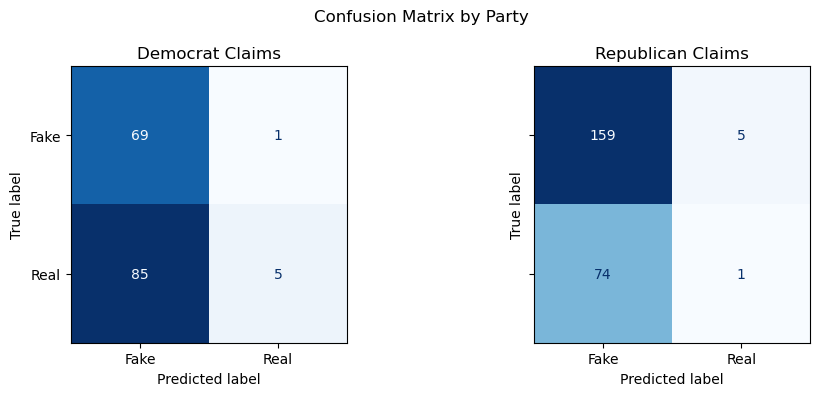

In [15]:
#plot confusion matrices separately for Democrat and Republican claims
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, party in zip(axes, ['democrat', 'republican']):
    party_data = filtered_news[filtered_news['party_affiliation'] == party]
    cm = confusion_matrix(
        party_data['true_label'],
        party_data['pred_label'],
        labels=[0, 1]
    )
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Fake', 'Real']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'{party.title()} Claims')

fig.suptitle('Confusion Matrix by Party')
plt.tight_layout()
plt.show()


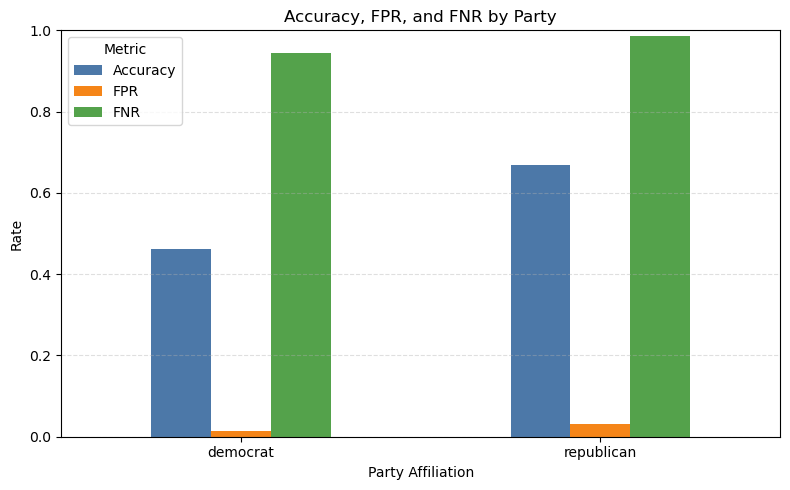

In [16]:
#plot accuracy, false positive rate, and false negative rate by party
core_metrics = mf_political.by_group[
    ['accuracy', 'false_positive_rate', 'false_negative_rate']
].rename(columns={
    'accuracy': 'Accuracy',
    'false_positive_rate': 'FPR',
    'false_negative_rate': 'FNR'
})

ax = core_metrics.plot(
    kind='bar',
    figsize=(8, 5),
    rot=0,
    color=['#4C78A8', '#F58518', '#54A24B']
)

plt.title('Accuracy, FPR, and FNR by Party')
plt.xlabel('Party Affiliation')
plt.ylabel('Rate')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


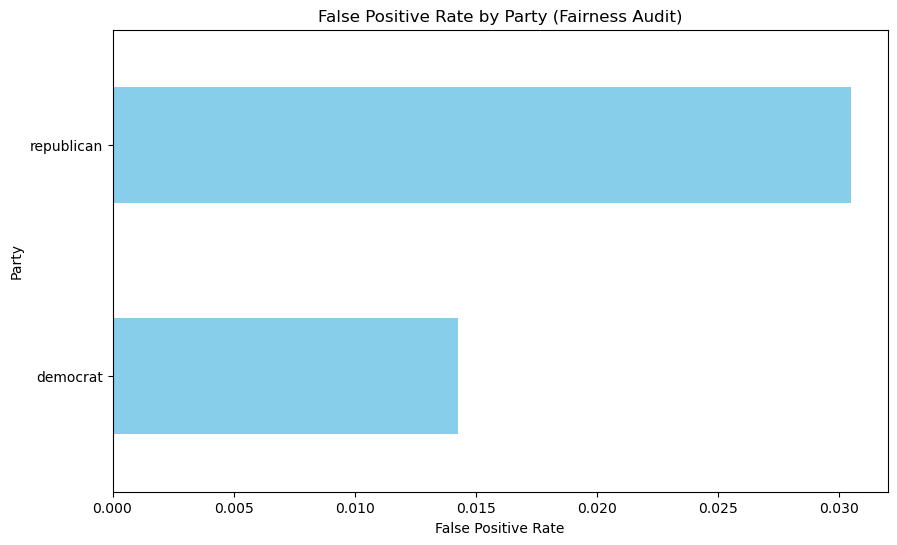

In [17]:
#visualize false positive rate by political party
import matplotlib.pyplot as plt

# Plotting False Positive Rate by Group
mf_political.by_group['false_positive_rate'].sort_values().plot(
    kind='barh', 
    figsize=(10, 6), 
    color='skyblue',
    title='False Positive Rate by Party (Fairness Audit)'
)
plt.xlabel('False Positive Rate')
plt.ylabel('Party')
plt.show()

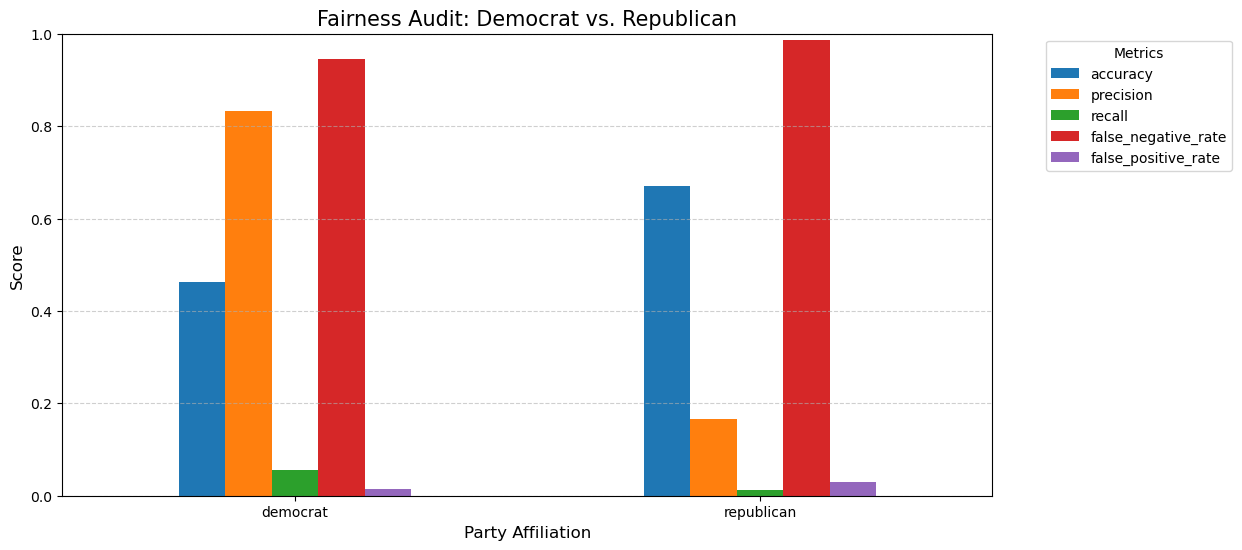

In [18]:
#visualize all fairness metrics by political party
import matplotlib.pyplot as plt

# Plot all metrics side-by-side
ax = mf_political.by_group.plot(
    kind='bar', 
    figsize=(12, 6), 
    rot=0,
    ylim=(0, 1) # Metrics are between 0 and 1
)

plt.title("Fairness Audit: Democrat vs. Republican", fontsize=15)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Party Affiliation", fontsize=12)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

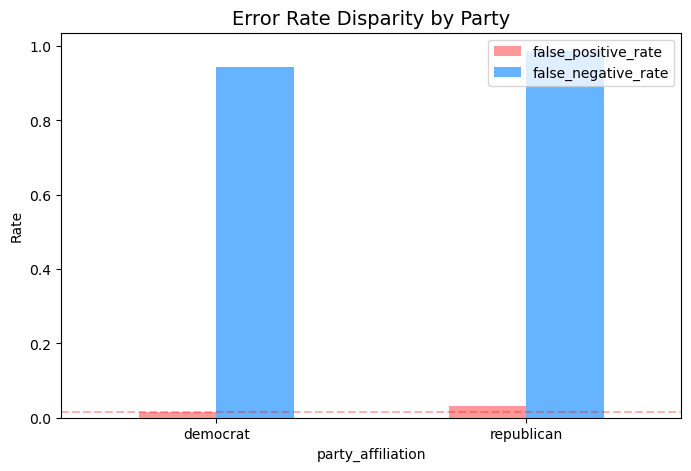

In [19]:
# Focus specifically on error rates
error_metrics = mf_political.by_group[['false_positive_rate', 'false_negative_rate']]

error_metrics.plot(
    kind='bar', 
    color=['#ff9999','#66b3ff'], 
    figsize=(8, 5),
    rot=0
)

plt.title("Error Rate Disparity by Party", fontsize=14)
plt.ylabel("Rate")
plt.axhline(y=error_metrics.loc['democrat', 'false_positive_rate'], color='red', linestyle='--', alpha=0.3)
plt.show()

## SHAP Error Explanation
Inspect one misclassified Republican example to see which words pushed the model prediction.


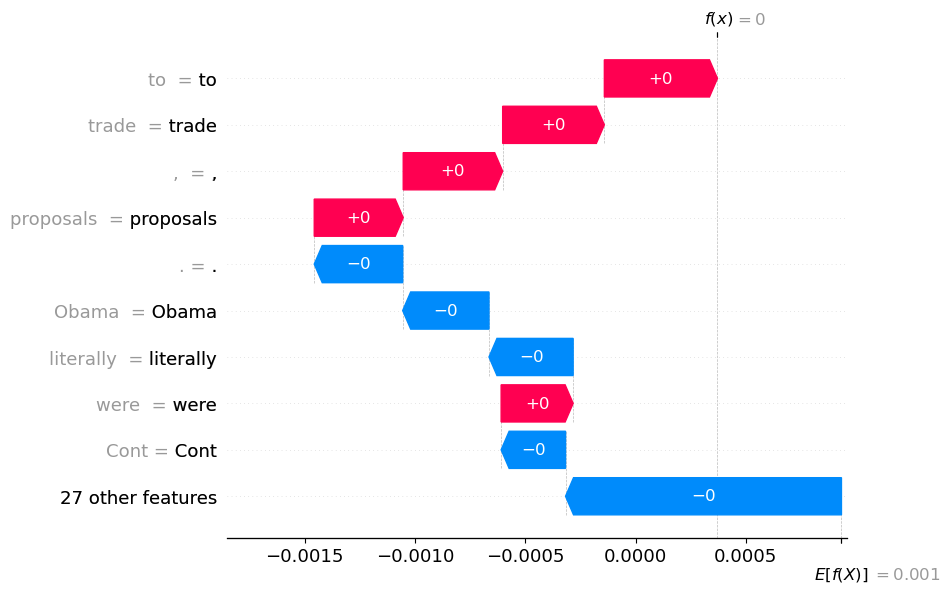

In [20]:
#explain one model mistake using SHAP token attributions
import shap
from transformers import pipeline


model.to("cpu")
model.eval()

# 2. Define a SHAP-specific prediction function
# SHAP sends a list of strings; this function must return a numpy array of probabilities
def predict_shap(texts):
    inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt").to("cpu")
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.detach().numpy()

# 3. Initialize the Explainer
explainer = shap.Explainer(predict_shap, masker=shap.maskers.Text(tokenizer), output_names=['Fake', 'Real'])

# 4. Identify Republican mistakes (where the model was wrong)
# Using 'clear_news_to_test' as per your dataset variable
republican_mistakes = clear_news_to_test[
    (clear_news_to_test['party_affiliation'] == 'republican') & 
    (clear_news_to_test['true_label'] != clear_news_to_test['pred_label'])
].copy()

# 5. Correctly format one available mistake as SHAP input
# iloc[4] can fail if there are fewer than five Republican mistakes.
if republican_mistakes.empty:
    print("No misclassified Republican examples were found, so there is no SHAP mistake to explain.")
else:
    example_position = min(4, len(republican_mistakes) - 1)
    test_statement = [str(republican_mistakes['statement'].iloc[example_position])]

    # 6. Run the explanation
    shap_values = explainer(test_statement)

    # 7. Visualize
    # This shows which words pushed the model toward the 'Real' prediction
    shap.plots.waterfall(shap_values[0, :, "Real"])